## Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, balanced_accuracy_score,
    average_precision_score, brier_score_loss,
)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import joblib
from pathlib import Path

## Data Loading

In [2]:
TRAIN_PATH = "../../data/transformed/train_t03.parquet"
VAL_PATH   = "../../data/transformed/val_t03.parquet"
TEST_PATH  = "../../data/transformed/test_t03.parquet"

TARGET   = "Results"

train = pd.read_parquet(TRAIN_PATH)
val   = pd.read_parquet(VAL_PATH)
test  = pd.read_parquet(TEST_PATH)

FEATURES = [col for col in train.columns if col != TARGET]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"\nTarget distribution (train):\n{y_train.value_counts()}")

Train: (109693, 16) | Val: (27483, 16) | Test: (34294, 16)

Target distribution (train):
Results
0    77306
1    32387
Name: count, dtype: int64


## Feature Scaling

In [3]:
# KNN relies entirely on distances so scaling is mandatory
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print(f"Feature means (should be ~0): {X_train_scaled.mean(axis=0).round(2)}")
print(f"Feature stds  (should be ~1): {X_train_scaled.std(axis=0).round(2)}")

Scaling complete.
Feature means (should be ~0): [ 0. -0. -0. -0. -0.  0. -0. -0. -0. -0. -0.  0. -0.  0.  0. -0.]
Feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Undersampling

In [4]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_scaled, y_train)

print(f"Before: {y_train.value_counts().to_dict()}")
print(f"After:  {pd.Series(y_train_resampled).value_counts().to_dict()}")

Before: {0: 77306, 1: 32387}
After:  {0: 32387, 1: 32387}


## Hyperparamter Definition

In [5]:
params = {
    "n_neighbors": 21,
    "weights":     "distance",
    "metric":      "euclidean",
    "n_jobs":      -1,
}

## Model Training

In [6]:
model = KNeighborsClassifier(**params)
model.fit(X_train_resampled, y_train_resampled)
print("Model ready.")
print(f"Training points stored: {model.n_samples_fit_}")

Model ready.
Training points stored: 64774


## Validation

In [7]:
def evaluate(model, X, y, split_name):
    y_pred       = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    cm           = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # --- derived rates ---
    fnr = fn / (fn + tp)
    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    # --- metrics ---
    roc_auc       = roc_auc_score(y, y_pred_proba)
    pr_auc        = average_precision_score(y, y_pred_proba)
    brier         = brier_score_loss(y, y_pred_proba)
    mcc           = matthews_corrcoef(y, y_pred)
    bal_acc       = balanced_accuracy_score(y, y_pred)
    f1_fail       = f1_score(y, y_pred, pos_label=1, zero_division=0)
    f1_pass       = f1_score(y, y_pred, pos_label=0, zero_division=0)
    f1_weighted   = f1_score(y, y_pred, average='weighted', zero_division=0)
    prec_fail     = precision_score(y, y_pred, pos_label=1, zero_division=0)
    recall_fail   = recall_score(y, y_pred, pos_label=1, zero_division=0)

    print(f'=== {split_name} ===')
    print(classification_report(y, y_pred, target_names=['Pass', 'Fail']))

    print('── Key Rates ──')
    print(f'  Sensitivity (Recall Fail):           {tpr:.4f}')
    print(f'  Specificity (Recall Pass):           {tnr:.4f}')
    print(f'  False Negative Rate (missed fails):  {fnr:.4f}')
    print(f'  False Positive Rate (wasted insp.):  {fpr:.4f}')

    print('── Model Quality ──')
    print(f'  ROC-AUC:                             {roc_auc:.4f}')
    print(f'  PR-AUC:                              {pr_auc:.4f}')
    print(f'  Brier Score (lower = better):        {brier:.4f}')
    print(f'  MCC:                                 {mcc:.4f}')
    print(f'  Balanced Accuracy:                   {bal_acc:.4f}')

    print('── Per Class ──')
    print(f'  Precision — Fail:                    {prec_fail:.4f}')
    print(f'  Recall    — Fail:                    {recall_fail:.4f}')
    print(f'  F1        — Fail:                    {f1_fail:.4f}')
    print(f'  F1        — Pass:                    {f1_pass:.4f}')
    print(f'  F1        — Weighted:                {f1_weighted:.4f}')
    print()

    metrics = {
        # counts
        'tp'                 : int(tp),
        'tn'                 : int(tn),
        'fp'                 : int(fp),
        'fn'                 : int(fn),
        # rates
        'sensitivity'        : tpr,
        'specificity'        : tnr,
        'false_negative_rate': fnr,
        'false_positive_rate': fpr,
        # model quality
        'accuracy'           : accuracy_score(y, y_pred),
        'balanced_accuracy'  : bal_acc,
        'roc_auc'            : roc_auc,
        'pr_auc'             : pr_auc,
        'brier_score'        : brier,
        'mcc'                : mcc,
        # per class
        'precision_fail'     : prec_fail,
        'recall_fail'        : recall_fail,
        'f1_fail'            : f1_fail,
        'f1_pass'            : f1_pass,
        'f1_weighted'        : f1_weighted,
    }

    return y_pred_proba, cm, metrics

print("Predicting on all splits... (this may take a few minutes for val and test)")
train_probas, train_cm, train_metrics = evaluate(model, X_train_scaled, y_train, 'Train')
val_probas,   val_cm,   val_metrics   = evaluate(model, X_val_scaled,   y_val,   'Validation')
test_probas, test_cm, test_metrics = evaluate(model, X_test_scaled, y_test, 'Test')

Predicting on all splits... (this may take a few minutes for val and test)
=== Train ===
              precision    recall  f1-score   support

        Pass       1.00      0.86      0.93     77306
        Fail       0.75      1.00      0.86     32387

    accuracy                           0.90    109693
   macro avg       0.88      0.93      0.89    109693
weighted avg       0.93      0.90      0.91    109693

── Key Rates ──
  Sensitivity (Recall Fail):           0.9983
  Specificity (Recall Pass):           0.8640
  False Negative Rate (missed fails):  0.0017
  False Positive Rate (wasted insp.):  0.1360
── Model Quality ──
  ROC-AUC:                             0.9987
  PR-AUC:                              0.9947
  Brier Score (lower = better):        0.0650
  MCC:                                 0.8062
  Balanced Accuracy:                   0.9311
── Per Class ──
  Precision — Fail:                    0.7546
  Recall    — Fail:                    0.9983
  F1        — Fail:       

## Confusion Matrices

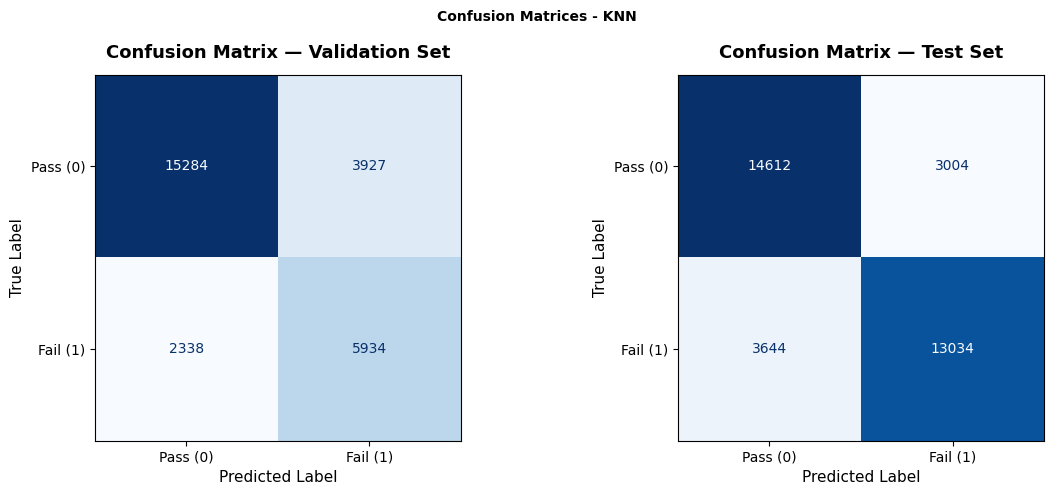

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
    axes,
    [val_cm, test_cm],
    ["Validation Set", "Test Set"]
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Pass (0)", "Fail (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {title}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

plt.suptitle("Confusion Matrices - KNN", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_knn.png", dpi=150, bbox_inches="tight")
plt.show()

## MLflow Exporting

In [9]:
summary = pd.DataFrame({
    'Split'              : ['Train', 'Val', 'Test'],
    'Accuracy'           : [train_metrics['accuracy'],            val_metrics['accuracy'],            test_metrics['accuracy']],
    'Balanced Accuracy'  : [train_metrics['balanced_accuracy'],   val_metrics['balanced_accuracy'],   test_metrics['balanced_accuracy']],
    'F1 (weighted)'      : [train_metrics['f1_weighted'],         val_metrics['f1_weighted'],         test_metrics['f1_weighted']],
    'F1 — Fail'          : [train_metrics['f1_fail'],             val_metrics['f1_fail'],             test_metrics['f1_fail']],
    'ROC-AUC'            : [train_metrics['roc_auc'],             val_metrics['roc_auc'],             test_metrics['roc_auc']],
    'PR-AUC'             : [train_metrics['pr_auc'],              val_metrics['pr_auc'],              test_metrics['pr_auc']],
    'MCC'                : [train_metrics['mcc'],                 val_metrics['mcc'],                 test_metrics['mcc']],
    'FNR (missed fails)' : [train_metrics['false_negative_rate'], val_metrics['false_negative_rate'], test_metrics['false_negative_rate']],
    'Catch Rate'         : [train_metrics['sensitivity'],         val_metrics['sensitivity'],         test_metrics['sensitivity']],
}).set_index('Split').round(4)

display(summary)

,Accuracy,Balanced Accuracy,F1 (weighted),F1 — Fail,ROC-AUC,PR-AUC,MCC,FNR (missed fails),Catch Rate
Split,,,,,,,,,
Train,0.9036,0.9311,0.9069,0.8595,0.9987,0.9947,0.8062,0.0017,0.9983
Val,0.7720,0.7565,0.7771,0.6545,0.8398,0.7107,0.4905,0.2826,0.7174
Test,0.8061,0.8055,0.8060,0.7968,0.8870,0.8881,0.6120,0.2185,0.7815


## Save Results
needs to save both model & scaler since KNN requires scaled input at inference time

In [10]:
models_dir = Path.cwd().parent.parent / 'models'
models_dir.mkdir(exist_ok=True)

joblib.dump(model,  models_dir / 'knn.pkl')
joblib.dump(scaler, models_dir / 'knn_scaler.pkl')
print(f'Model saved to {models_dir / "knn.pkl"}')
print(f'Scaler saved to {models_dir / "knn_scaler.pkl"}')

Model saved to /home/engomar/Desktop/Year_04_Spring_2026/Data_Science/CMPS344_Project/Food-Inspection/models/knn.pkl
Scaler saved to /home/engomar/Desktop/Year_04_Spring_2026/Data_Science/CMPS344_Project/Food-Inspection/models/knn_scaler.pkl


## MLflow Logging

In [11]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("../../mlruns")
mlflow.set_experiment("food-inspection-classification")

with mlflow.start_run(run_name="knn"):

    # --- hyperparameters ---
    mlflow.log_params(params)
    mlflow.log_param("imbalance_strategy", "RandomUnderSampler")

    # --- standard metrics ---
    mlflow.log_metric("test_accuracy",          test_metrics['accuracy'])
    mlflow.log_metric("test_balanced_accuracy", test_metrics['balanced_accuracy'])
    mlflow.log_metric("test_f1_weighted",       test_metrics['f1_weighted'])
    mlflow.log_metric("test_f1_fail",           test_metrics['f1_fail'])
    mlflow.log_metric("test_f1_pass",           test_metrics['f1_pass'])
    mlflow.log_metric("test_mcc",               test_metrics['mcc'])
    mlflow.log_metric("test_pr_auc",            test_metrics['pr_auc'])
    mlflow.log_metric("test_brier_score",       test_metrics['brier_score'])
    mlflow.log_metric("test_precision_fail",    test_metrics['precision_fail'])
    mlflow.log_metric("test_recall_fail",       test_metrics['recall_fail'])

    # --- business metrics ---
    mlflow.log_metric("test_false_negative_rate", test_metrics['false_negative_rate'])
    mlflow.log_metric("test_false_positive_rate", test_metrics['false_positive_rate'])
    mlflow.log_metric("test_failing_catch_rate",  test_metrics['sensitivity'])

    # --- val + test roc ---
    mlflow.log_metric("val_roc_auc",  val_metrics['roc_auc'])
    mlflow.log_metric("test_roc_auc", test_metrics['roc_auc'])

    # --- model artifact ---
    mlflow.sklearn.log_model(model, artifact_path="model")

    # --- plot artifacts ---
    mlflow.log_artifact("confusion_matrix_knn.png")

    run_id = mlflow.active_run().info.run_id
    print(f"Run logged. ID: {run_id}")

/home/engomar/.cache/pypoetry/virtualenvs/science-the-data-CK6af-Of-py3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/engomar/.cache/pypoetry/virtualenvs/science-the-data-CK6af-Of-py3.13/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/04 21:55:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 21:55:25 WARNING mlflow.sklearn: Saving scikit-learn models

Run logged. ID: 825e06e366ca49e3a6319c553b889118
